## Importing of libraries:

This cell is used to import the python libraries necessary for our machine learning, data analysis and data visualisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler


## Loading Dataset: 

Spotify dataset loaded using pandas. Key columns at this stage are id, track artist, track_album_id and track_name. These are important as we can see the dataset is identified correctly.

In [2]:
music = pd.read_csv("high_popularity_spotify_data.csv")
print("Data Shape:", music.shape)

Data Shape: (1686, 29)


## Copying The Dataset
Important general step to maintain the integrity of the original dataset. 

In [3]:
music_copy = music.copy()

## Dataset Cleaning and Wrangling
Sorting Dataset by author - (A-Z)

In [4]:
music_copy = music_copy.sort_values(by="track_artist")
music_copy.head(5)

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
1005,0.928,172.656,0.614,pop,-4.806,0.0845,0.879,*NSYNC,4,0.0516,...,0.001040,5hMd4vAfSUT1cbYCnRUako,0,8,200560,0.04080,4r8lRYnoOGdEi6YyI5OC1o,throwback,audio_features,37i9dQZF1DX7F6T2n2fegs
1618,0.149,82.019,0.485,electronic,-20.394,0.1020,0.112,".diedlonely, énouement",4,0.0282,...,0.917000,4gF0aKdd26DsLMbDcLdJdc,0,8,99672,0.88600,2PpYJcgJN6PzozUv7rU669,vaporwave,audio_features,37i9dQZF1EIdOtkojz5FWw
490,0.733,172.090,0.625,gaming,-8.757,0.3750,0.244,21 Savage,4,0.0488,...,0.000983,2RRYaYHY7fIIdvFlvgb5vq,1,2,270698,0.00598,52eIcoLUM25zbQupAZYoFh,modern,audio_features,37i9dQZF1DWTyiBJ6yEqeu
1460,0.636,145.972,0.837,hip-hop,-7.643,0.3420,0.274,21 Savage,4,0.0860,...,0.001250,007DWn799UWvfY1wwZeENR,1,1,288624,0.03950,2t8yVaLvJ0RenpXUIAC52d,chill,audio_features,37i9dQZF1EIf4OaZ1XTJYw
765,0.347,75.016,0.884,arabic,-8.227,0.0871,0.376,21 Savage,4,0.3500,...,0.000007,4skCiJhVVSKrDOBtoFbsxU,0,8,220307,0.01500,5eqK0tbzUPo2SoeZsov04s,modern,audio_features,3gZgGRvDn9tTUy8n7699pD


## Data Visualization

Two graphs showing the top genres and artists within the datast.

In [5]:
music_copy.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
1005,0.928,172.656,0.614,pop,-4.806,0.0845,0.879,*NSYNC,4,0.0516,...,0.001040,5hMd4vAfSUT1cbYCnRUako,0,8,200560,0.04080,4r8lRYnoOGdEi6YyI5OC1o,throwback,audio_features,37i9dQZF1DX7F6T2n2fegs
1618,0.149,82.019,0.485,electronic,-20.394,0.1020,0.112,".diedlonely, énouement",4,0.0282,...,0.917000,4gF0aKdd26DsLMbDcLdJdc,0,8,99672,0.88600,2PpYJcgJN6PzozUv7rU669,vaporwave,audio_features,37i9dQZF1EIdOtkojz5FWw
490,0.733,172.090,0.625,gaming,-8.757,0.3750,0.244,21 Savage,4,0.0488,...,0.000983,2RRYaYHY7fIIdvFlvgb5vq,1,2,270698,0.00598,52eIcoLUM25zbQupAZYoFh,modern,audio_features,37i9dQZF1DWTyiBJ6yEqeu
1460,0.636,145.972,0.837,hip-hop,-7.643,0.3420,0.274,21 Savage,4,0.0860,...,0.001250,007DWn799UWvfY1wwZeENR,1,1,288624,0.03950,2t8yVaLvJ0RenpXUIAC52d,chill,audio_features,37i9dQZF1EIf4OaZ1XTJYw
765,0.347,75.016,0.884,arabic,-8.227,0.0871,0.376,21 Savage,4,0.3500,...,0.000007,4skCiJhVVSKrDOBtoFbsxU,0,8,220307,0.01500,5eqK0tbzUPo2SoeZsov04s,modern,audio_features,3gZgGRvDn9tTUy8n7699pD


In [6]:
music_copy.describe()

,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,track_popularity,instrumentalness,mode,key,duration_ms,acousticness
count,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000
mean,0.667216,121.070938,0.650362,-6.704131,0.171579,0.525737,3.950178,0.100926,75.806050,0.041520,0.578292,5.338078,214562.125741,0.221220
std,0.184908,27.066029,0.157721,3.377068,0.123953,0.236113,0.326673,0.099748,6.032532,0.156556,0.493979,3.608208,58310.747929,0.250593
min,0.001610,49.305000,0.136000,-43.643000,0.021000,0.034800,1.000000,0.023200,68.000000,0.000000,0.000000,0.000000,61673.000000,0.000013
25%,0.551000,100.058750,0.543250,-7.950250,0.093400,0.339000,4.000000,0.037900,71.000000,0.000000,0.000000,2.000000,176607.750000,0.023050
50%,0.689000,120.001000,0.664500,-5.974500,0.121000,0.528000,4.000000,0.058100,75.000000,0.000006,1.000000,5.000000,211180.000000,0.124000
75%,0.807000,136.833500,0.769000,-4.687250,0.210000,0.720000,4.000000,0.118000,79.000000,0.000814,1.000000,8.000000,244993.250000,0.334750
max,0.990000,209.688000,0.979000,1.295000,0.950000,0.978000,5.000000,0.848000,100.000000,0.971000,1.000000,11.000000,547107.000000,0.995000


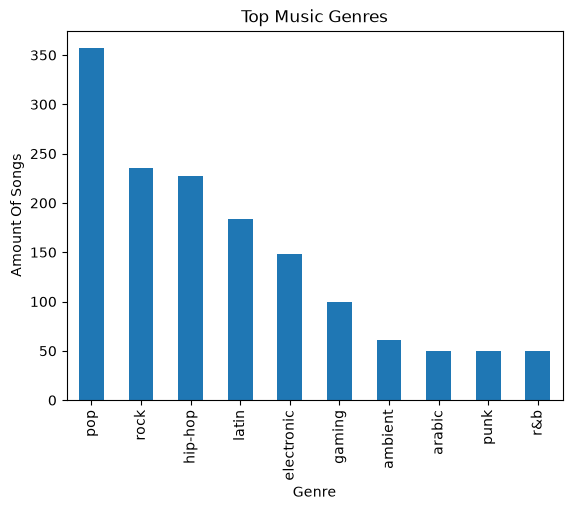

In [ ]:
music_copy["playlist_genre"].value_counts().head(10).plot(kind='bar')
plt.title("Top Music Genres")
plt.xlabel("Genre")
plt.ylabel("Amount Of Songs In Dataset")
plt.show()

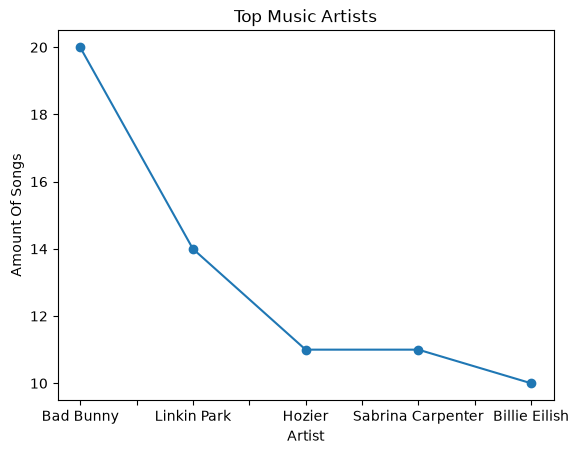

In [ ]:
music_copy["track_artist"].value_counts().head(5).plot(kind='line', marker=("o"))
plt.title("Top Music Artists")
plt.xlabel("Artist")
plt.ylabel("Amount Of Songs In Dataset")
plt.show()

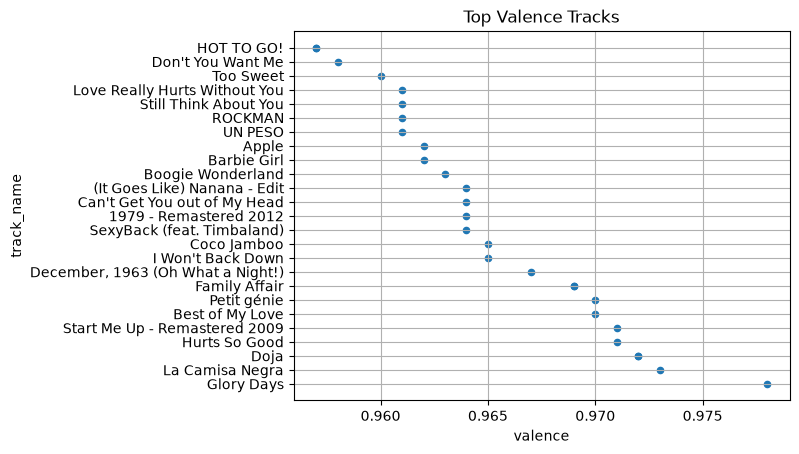

In [9]:
music_copy.sort_values(by="valence" , ascending=False).head(28).plot(
    kind='scatter', 
    x="valence", 
    y="track_name", 
    grid=True)
plt.title("Top Valence Tracks")
plt.show()

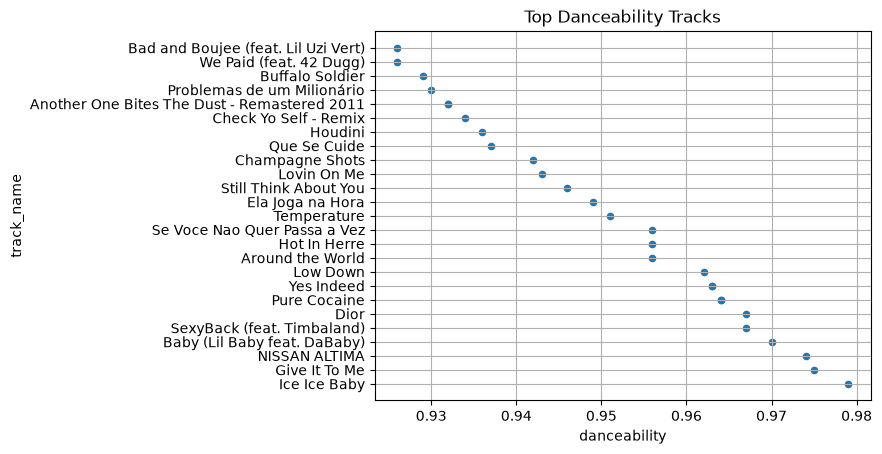

In [10]:
music_copy.sort_values(by="danceability", ascending=False).head(28).plot(
    kind='scatter', 
    x="danceability", 
    y="track_name", 
    grid=True)
plt.title("Top Danceability Tracks")
plt.show()

## Features and User Menu

This asks the user for the 3 features of their choice, then stores the user decisions in user_features[ ]. 

In [11]:
def feature_menu():
    features = [
    "energy",
    "tempo",
    "loudness",
    "liveness",
    "danceability",
    "valence",
    "speechiness"
    ]

    user_features = []

    print("*" * 41)
    print("\t\tVARIABLE MENU\t\t")
    print(f"*1. energy \t\t\t\t*")
    print(f"*2. tempo \t\t\t\t*")
    print(f"*3. loudness \t\t\t\t*")
    print(f"*4. liveness \t\t\t\t*")
    print(f"*5. danceability \t\t\t*")
    print(f"*6. valence \t\t\t\t*")
    print(f"*7. speechiness \t\t\t*")
    print("*" * 41)

    choice_one = int(input("Please Choose Your First Variable(1-7): "))
    user_features.append(features[choice_one - 1])
    

    choice_two = int(input("Please Choose Your Second Variable(1-7): "))
    user_features.append(features[choice_two - 1])
    

    choice_three = int(input("Please Choose Your Third Variable(1-7): "))
    user_features.append(features[choice_three - 1])
    

    return user_features

user_features = feature_menu()

print("The features you have selected: ")
print(user_features)


*****************************************
		VARIABLE MENU		
*1. energy 				*
*2. tempo 				*
*3. loudness 				*
*4. liveness 				*
*5. danceability 			*
*6. valence 				*
*7. speechiness 			*
*****************************************
The features you have selected: 
['energy', 'tempo', 'loudness']


This is the features and the shape of the features chosen and track popularity.

In [12]:
features = [
    "energy",
    "tempo",
    "loudness",
    "liveness",
    "danceability",
    "valence",
    "speechiness"
    ]

X = music_copy[user_features]
y = music_copy["track_popularity"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1686, 3)
y Shape: (1686,)


Creating Test/Train Set.

In [13]:
split = int(len(music_copy) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train Size(X)(Y)", X_train.shape, y_train.shape)
print("Test Size(X)(Y)", X_test.shape, y_test.shape)

Train Size(X)(Y) (1348, 3) (1348,)
Test Size(X)(Y) (338, 3) (338,)


## Machine Learning Algorithms

Random Forest, MAE (Mean Absolute Error) Shows the average of errors and RMSE (Root Mean Squared Error) where bigger errors outweigh smaller / average errors.

In [14]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE", rmse)

Random Forest MAE: 5.38299661876585
Random Forest RMSE 6.574796311437662


Linear Regression, using standard scaler to scale and transform data to work with the model.

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression(
)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression RMSE", rmse)

Linear Regression MAE: 5.226585754161266
Linear Regression RMSE 6.3556916396675005


Decision Tree, uses branch like structure, splitting data between features.

In [16]:
dt = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree MAE:", mean_absolute_error(y_test, y_pred_dt))

rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
print("Decision Tree RMSE", rmse)

Decision Tree MAE: 5.373712048550001
Decision Tree RMSE 6.473489212408449


## User Menu

Menu in which asks the user to enter each song to be entered into the battle for the "Better Song".

In [17]:
def song_menu():
    print("*" * 29)
    print("PLEASE ENTER EXACT SONG NAME")
    print("*" * 29)
    song_one = input("Please Enter User One's Song: ")
    song_two = input("Please Enter User Two's Song: ")
    return song_one, song_two

song_one, song_two = song_menu()
print("Song One:", song_one)
print("Song Two:", song_two)
print("*" * 29)



*****************************
PLEASE ENTER EXACT SONG NAME
*****************************
Song One: Not Like Us
Song Two: Espresso
*****************************


Function in which searches the dataset for the song entered by the user.

In [18]:
def search_song(song_one, song_two, music_copy):
    song_one_info = music_copy[
        music_copy["track_name"].str.lower() == song_one.lower()
    ]
    song_two_info = music_copy[
        music_copy["track_name"].str.lower() == song_two.lower()
    ]

    song_one_info = song_one_info
    song_two_info = song_two_info

    return song_one_info, song_two_info


Function in which compares the songs in the dataset from the user inputs and decides a winner.

In [19]:
def song_battle(song_one, song_two, user_features, music_copy, model="random_forest"):
    song_one_data, song_two_data = search_song(
        song_one, song_two, music_copy
    )

    if song_one_data is None or song_two_data is None:
        print("Song Battle Error...")
        song_menu()
    
    features_one = song_one_data[user_features]
    features_two = song_two_data[user_features]

    if model == "random_forest":
        y_pred_one = rf.predict(features_one)[0]
        y_pred_two = rf.predict(features_two)[0]

    elif model == "linear":
        scaler_one = scaler.transform(features_one)
        scaler_two = scaler.transform(features_two)

        y_pred_one = lr.predict(scaler_one)[0]
        y_pred_two = lr.predict(scaler_two)[0]

    elif model == "decision_tree":
        y_pred_one = dt.predict(features_one)[0]
        y_pred_two = dt.predict(features_two)[0]
    else:
        print("You have not entered a correct model.")
        return None

    if y_pred_one > y_pred_two:
        print("The Winner Has Been Decided As:", song_one)
        print("Track Popularity Prediction: %", y_pred_one)
        return song_one
    elif y_pred_one < y_pred_two:
        print("The Winner Has Been Decided As: ", song_two)
        print("Track Popularity Prediction: %", y_pred_two)
        return song_two
    else: 
        print("The Models Are Tied.")

Printing the results of the song_battle function.

In [20]:
print("Random Forest") 
rf_result = song_battle(song_one, song_two, user_features, music_copy, model="random_forest")
print( )
print("Linear Regression") 
lr_result = song_battle(song_one, song_two, user_features, music_copy, model="linear")
print( )
print("Decision Tree") 
dt_result = song_battle(song_one, song_two, user_features, music_copy, model="decision_tree")
print( )


Random Forest
The Winner Has Been Decided As: Not Like Us
Track Popularity Prediction: % 87.66

Linear Regression
The Winner Has Been Decided As: Not Like Us
Track Popularity Prediction: % 76.50781669618681

Decision Tree
The Models Are Tied.



Scorecard to finalise results.

In [21]:
scorecard_one = 0
scorecard_two = 0 

for i in [rf_result, lr_result, dt_result]:
    if i == song_one:
        scorecard_one += 1
    
    else:
        scorecard_two +=1

print("*" * 29)
print("JUDGE'S SCORECARD")
print("*" * 29)
print("Judge One: Random Forest")
print("Judge Two: Linear Regression")
print("Judge Three: Decision Tree")
print("*" * 29)

if scorecard_two == 0:
    print("Unanimous Decision: ", song_one, "With", scorecard_one, "Votes.")
    print("*" * 43)
elif scorecard_one == 0:
    print("Unanimous Decision: ", song_two, "With", scorecard_two, "Votes.")
    print("*" * 43)
elif scorecard_one > scorecard_two:
    print("Your Winner Is: ", song_one, "With", scorecard_one, "Votes.")
    print("*" * 43)
elif scorecard_one < scorecard_two:
    print("Your Winner Is: ", song_two, "With", scorecard_two, "Votes.")
    print("*" * 43)
else:
    print("Techincal Issues :/")


*****************************
JUDGE'S SCORECARD
*****************************
Judge One: Random Forest
Judge Two: Linear Regression
Judge Three: Decision Tree
*****************************
Your Winner Is:  Not Like Us With 2 Votes.
*******************************************
